In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving honeyproduction.csv to honeyproduction.csv


# Langkah 1

In [3]:
# Load data dan menampilkan 5 baris pertama
df = pd.read_csv('honeyproduction.csv')
df.head(5)

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


In [10]:
# Deteksi tipe data
df.dtypes

,0
state,object
numcol,float64
yieldpercol,int64
totalprod,float64
stocks,float64
priceperlb,float64
prodvalue,float64
year,int64


In [11]:
# Deteksi data null
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
state,5,0.789889
numcol,5,0.789889
priceperlb,5,0.789889


In [16]:
# Deteksi data duplikat
df[df.duplicated(keep=False)]

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
50,HI,8000.0,80,640000.0,32000.0,0.80,512000.0,1999
51,ID,120000.0,48,5760000.0,3110000.0,0.59,3398000.0,1999
52,IL,9000.0,66,594000.0,327000.0,1.15,683000.0,1999
53,IN,10000.0,81,810000.0,437000.0,0.90,729000.0,1999
54,IA,40000.0,65,2600000.0,2028000.0,0.65,1690000.0,1999
55,KS,13000.0,67,871000.0,854000.0,1.11,967000.0,1999
56,KY,3000.0,50,150000.0,12000.0,1.24,186000.0,1999
626,HI,8000.0,80,640000.0,32000.0,0.80,512000.0,1999
627,ID,120000.0,48,5760000.0,3110000.0,0.59,3398000.0,1999
628,IL,9000.0,66,594000.0,327000.0,1.15,683000.0,1999


In [18]:
# Hapus data duplikat
df.drop_duplicates(inplace=True)

# Cek hasil setelah cleaning
df.duplicated().sum()

np.int64(0)

In [21]:
# Menangani missing value pada kolom 'state' (object)
df['state'] = df['state'].fillna('unknown')

# Menangani missing value pada kolom 'numcol' (numerik)
median_numcol = df['numcol'].median()
df['numcol'] = df['numcol'].fillna(median_numcol)

# # Menangani missing value pada kolom 'priceperlb' (numerik)
median_priceperlb = df['priceperlb'].median()
df['priceperlb'] = df['priceperlb'].fillna(median_priceperlb)

# Langkah 2

In [23]:
# Menampilkan informasi data
df.describe()

,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
count,6.260000e+02,626.000000,6.260000e+02,6.260000e+02,626.000000,6.260000e+02,626.000000
mean,6.427955e+04,62.009585,4.169086e+06,1.318859e+06,1.412604,4.853511e+06,2004.864217
std,1.363415e+05,19.458754,6.883847e+06,2.272964e+06,0.637026,8.706776e+06,4.317306
min,2.000000e+03,19.000000,8.400000e+04,8.000000e+03,0.490000,1.620000e+05,1998.000000
25%,9.000000e+03,48.000000,4.750000e+05,1.430000e+05,0.942500,7.592500e+05,2001.000000
50%,2.600000e+04,60.000000,1.533000e+06,4.395000e+05,1.360000,1.841500e+06,2005.000000
75%,6.300000e+04,74.000000,4.175250e+06,1.489500e+06,1.680000,4.703250e+06,2009.000000
max,2.600000e+06,136.000000,4.641000e+07,1.380000e+07,4.150000,9.207500e+07,2012.000000


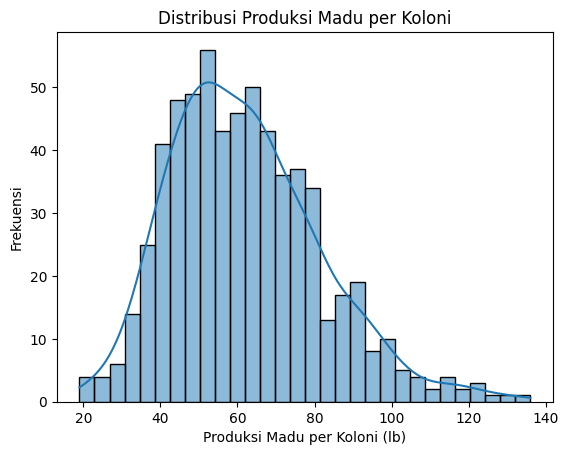

In [24]:
# Menampilkan data dalam bentuk histogram
sns.histplot(data=df,x='yieldpercol', bins=30,kde=True)

plt.title('Distribusi Produksi Madu per Koloni')
plt.xlabel('Produksi Madu per Koloni (lb)')
plt.ylabel('Frekuensi')
plt.show()

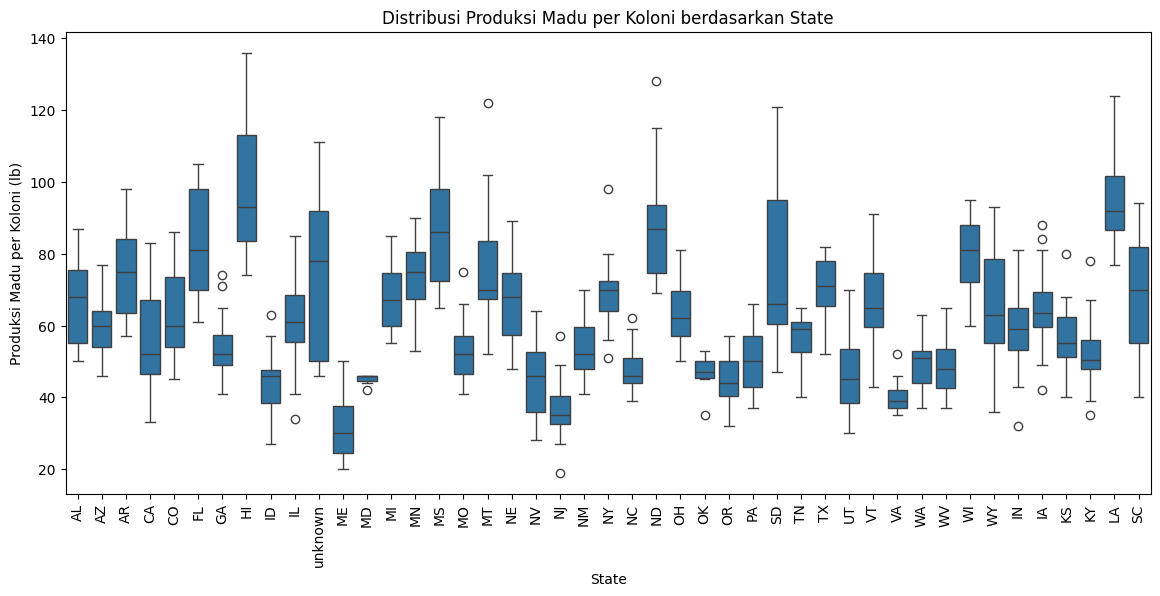

In [25]:
# Menampilkan data dalam bentuk Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="state", y="yieldpercol")

plt.title("Distribusi Produksi Madu per Koloni berdasarkan State")
plt.xlabel("State")
plt.ylabel("Produksi Madu per Koloni (lb)")
plt.xticks(rotation=90)
plt.show()

In [28]:
# Menampilkan skewness
df['yieldpercol'].skew()

np.float64(0.6934329288060218)

In [27]:
# Menghitung kombinasi data
df.value_counts()

state    numcol   yieldpercol  totalprod  stocks     priceperlb  prodvalue  year
unknown  50000.0  78           3900000.0  2301000.0  0.70        2730000.0  1998    1
AL       8000.0   54           432000.0   65000.0    2.47        1067000.0  2012    1
WY       37000.0  72           2664000.0  746000.0   0.61        1625000.0  1999    1
                  48           1776000.0  391000.0   1.43        2540000.0  2009    1
         35000.0  54           1890000.0  265000.0   1.72        3251000.0  2011    1
                                                                                   ..
AL       11000.0  72           792000.0   230000.0   1.21        958000.0   2006    1
                  56           616000.0   209000.0   1.49        918000.0   2007    1
         9000.0   66           594000.0   214000.0   1.90        1129000.0  2008    1
                  54           486000.0   73000.0    2.40        1166000.0  2010    1
                  50           450000.0   68000.0    1.86        837000.0   2009    1
Name: count, Length: 626, dtype: int64

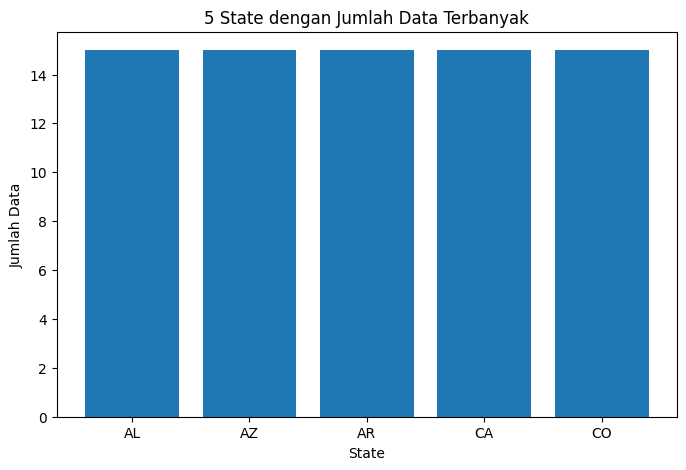

In [30]:
# Menampilkan data dalam bentuk bar chart

state_count = df['state'].value_counts().head(5)

plt.figure(figsize=(8, 5))

plt.bar(state_count.index, state_count.values)

plt.title("5 State dengan Jumlah Data Terbanyak")
plt.xlabel("State")
plt.ylabel("Jumlah Data")

plt.show()

# Langkah 3

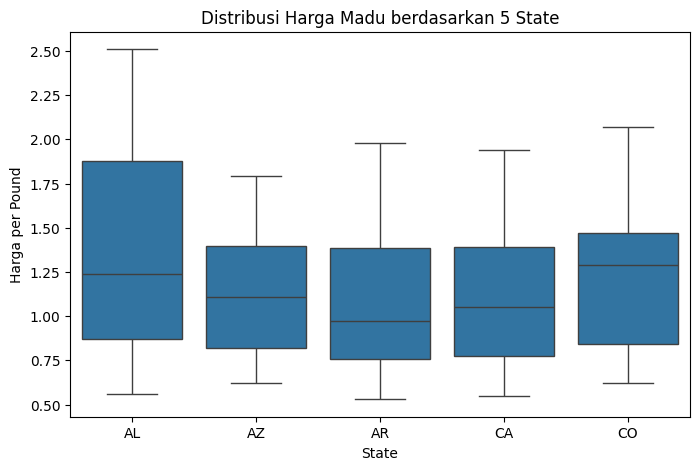

In [31]:
# Boxplot Kategorial to Numerik

top_5 = df['state'].value_counts().head(5).index

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[df['state'].isin(top_5)],
    x="state",
    y="priceperlb",
    order=top_5
)

plt.title("Distribusi Harga Madu berdasarkan 5 State")
plt.xlabel("State")
plt.ylabel("Harga per Pound")

plt.show()

In [32]:
# Membuat kolom baru yang menampilkan persentase stok (Feature Engineering)

df['stock_ratio_percent'] = (
    df['stocks'] / df['totalprod']
) * 100

df['stock_ratio_percent'].head(10)

,stock_ratio_percent
0,13.996479
1,45.000000
2,48.998549
3,33.001339
4,81.995885
5,20.000000
6,7.309524
7,6.991525
8,37.000000
9,31.924883


In [33]:
# Membuat kolom baru yang menampilkan nilai produk per koloni (Feature Engineering)

df['prodvalue_per_colony'] = (
    df['prodvalue'] / df['numcol']
)

df['prodvalue_per_colony'].head(10)

,prodvalue_per_colony
0,51.125000
1,38.400000
2,38.358491
3,51.460000
4,50.407407
5,62.721739
6,38.640000
7,90.875000
8,32.500000
9,84.444444


# Langkah 4

In [37]:
# Menampilkan jumlah data setiap kolom

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 626 entries, 0 to 625
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 626 non-null    object 
 1   numcol                626 non-null    float64
 2   yieldpercol           626 non-null    int64  
 3   totalprod             626 non-null    float64
 4   stocks                626 non-null    float64
 5   priceperlb            626 non-null    float64
 6   prodvalue             626 non-null    float64
 7   year                  626 non-null    int64  
 8   stock_ratio_percent   626 non-null    float64
 9   prodvalue_per_colony  626 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 53.8+ KB


In [36]:
# Mengecek hasil akhir apakah masih ada data yang kosong atau tidak

df.isnull().sum()

,0
state,0
numcol,0
yieldpercol,0
totalprod,0
stocks,0
priceperlb,0
prodvalue,0
year,0
stock_ratio_percent,0
prodvalue_per_colony,0


# DATA SIAP UNTUK TAHAP PREPROCESSING / FEATURE SCALING